In [73]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abirrouag/loan-datasets/train_u6lujuX_CVtuZ9i.csv


In [74]:
!pip install shap -q
!pip install xgboost -q


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [76]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Environment ready!")

Environment ready!


# Load and Understand Your Dataset

In [77]:
import pandas as pd


df = pd.read_csv('/kaggle/input/datasets/abirrouag/loan-datasets/train_u6lujuX_CVtuZ9i.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [78]:
print("=== DATASET LOADED SUCCESSFULLY ===")
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


=== DATASET LOADED SUCCESSFULLY ===
Dataset shape: (614, 13)
Number of rows: 614
Number of columns: 13


In [79]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2    

In [80]:
# Display all column names
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [81]:
# Display data types
print("\nData types:")
print(df.dtypes)


Data types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [82]:
# Display basic statistics
print("\nBasic Statistics:")
print(df.describe())


Basic Statistics:
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [83]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [84]:
# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


#  Identify the Target Variable

In [85]:
# Let's identify the target variable
print("=== IDENTIFYING TARGET VARIABLE ===\n")

=== IDENTIFYING TARGET VARIABLE ===



In [86]:
# Look for common target column names
target_candidates = ['Loan_Status', 'loan_status', 'default', 'Status', 'TARGET', 'target']

target_column = None
for col in df.columns:
    if col in target_candidates or 'status' in col.lower() or 'default' in col.lower():
        target_column = col
        break

if target_column:
    print(f"✅ Found target column: '{target_column}'")
    print(f"Unique values: {df[target_column].unique()}")
    print(f"Value counts:\n{df[target_column].value_counts()}")
    
    # Convert to binary (0/1) if needed
    if df[target_column].dtype == 'object':
        print("\nConverting categorical target to binary...")
        # Map 'Y' -> 1, 'N' -> 0 (common in loan datasets)
        if 'Y' in df[target_column].unique() or 'N' in df[target_column].unique():
            df['loan_status'] = df[target_column].map({'Y': 1, 'N': 0})
            print("✅ Mapped 'Y' -> 1 (Default), 'N' -> 0 (No Default)")
        else:
            # Try other common mappings
            unique_vals = df[target_column].unique()
            if len(unique_vals) == 2:
                # Convert to 0 and 1
                df['loan_status'] = (df[target_column] == unique_vals[1]).astype(int)
                print(f"✅ Mapped '{unique_vals[1]}' -> 1, '{unique_vals[0]}' -> 0")
    else:
        # Already numeric
        df['loan_status'] = df[target_column]
        print("✅ Target is already numeric")
else:
    print("❌ Target column not found automatically")
    print("Available columns:", df.columns.tolist())
    # Assume last column is target
    df['loan_status'] = df.iloc[:, -1]
    print(f"✅ Using last column as target: {df.columns[-1]}")

# Check if we have loan_status
if 'loan_status' in df.columns:
    print(f"\nFinal target distribution:")
    print(df['loan_status'].value_counts())
    print(f"Default rate: {df['loan_status'].mean()*100:.2f}%")

✅ Found target column: 'Loan_Status'
Unique values: ['Y' 'N']
Value counts:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Converting categorical target to binary...
✅ Mapped 'Y' -> 1 (Default), 'N' -> 0 (No Default)

Final target distribution:
loan_status
1    422
0    192
Name: count, dtype: int64
Default rate: 68.73%


# Identify Feature Types

In [87]:
print("\n=== FEATURE ANALYSIS ===\n")

# Identify column types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from feature lists
if 'loan_status' in numeric_cols:
    numeric_cols.remove('loan_status')
if 'loan_status' in categorical_cols:
    categorical_cols.remove('loan_status')

print(f"Numeric features: {len(numeric_cols)}")
print(numeric_cols)

print(f"\nCategorical features: {len(categorical_cols)}")
print(categorical_cols)

# Check for ID columns to remove
id_cols = [col for col in df.columns if 'id' in col.lower() or 'ID' in col]
if id_cols:
    print(f"\nFound ID columns to potentially remove: {id_cols}")

# Check for high cardinality categorical features
high_cardinality = []
for col in categorical_cols:
    if df[col].nunique() > 20:
        high_cardinality.append(col)
        print(f"⚠️ '{col}' has {df[col].nunique()} unique values (high cardinality)")


=== FEATURE ANALYSIS ===

Numeric features: 5
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical features: 8
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Found ID columns to potentially remove: ['Loan_ID']
⚠️ 'Loan_ID' has 614 unique values (high cardinality)


# Data Cleaning and Preprocessing

In [88]:
print("\n=== DATA CLEANING ===\n")

# 1. Remove ID columns if they exist
for col in ['Loan_ID', 'id', 'ID', 'customer_id']:
    if col in df.columns:
        df = df.drop(col, axis=1)
        print(f"✅ Removed ID column: {col}")

# 2. Handle missing values
print("\nHandling missing values...")
missing_percentage = (df.isnull().sum() / len(df)) * 100
columns_with_missing = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

if len(columns_with_missing) > 0:
    print("Columns with missing values:")
    print(columns_with_missing)
    
    # For numeric columns - fill with median
    for col in numeric_cols:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"✅ Filled missing in '{col}' with median: {df[col].median():.2f}")
    
    # For categorical columns - fill with mode
    for col in categorical_cols:
        if col in df.columns and df[col].isnull().sum() > 0:
            mode_value = df[col].mode()[0]
            df[col].fillna(mode_value, inplace=True)
            print(f"✅ Filled missing in '{col}' with mode: {mode_value}")
else:
    print("✅ No missing values found")

# 3. Handle outliers using IQR method
print("\nHandling outliers...")
for col in numeric_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers before capping
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            # Cap outliers
            df[col] = df[col].clip(lower_bound, upper_bound)
            print(f"✅ Capped {outliers} outliers in '{col}'")

# 4. Convert categorical columns to appropriate types
for col in categorical_cols:
    if col in df.columns:
        if df[col].dtype == 'object':
            # Convert to string and strip whitespace
            df[col] = df[col].astype(str).str.strip()
            print(f"✅ Cleaned categorical column: {col}")

print("\n=== DATA CLEANING COMPLETE ===")
print(f"Final dataset shape: {df.shape}")

# Show updated info
print("\nUpdated dataset info:")
print(df.info())


=== DATA CLEANING ===

✅ Removed ID column: Loan_ID

Handling missing values...
Columns with missing values:
Credit_History      8.143322
Self_Employed       5.211726
LoanAmount          3.583062
Dependents          2.442997
Loan_Amount_Term    2.280130
Gender              2.117264
Married             0.488599
dtype: float64
✅ Filled missing in 'LoanAmount' with median: 128.00
✅ Filled missing in 'Loan_Amount_Term' with median: 360.00
✅ Filled missing in 'Credit_History' with median: 1.00
✅ Filled missing in 'Gender' with mode: Male
✅ Filled missing in 'Married' with mode: Yes
✅ Filled missing in 'Dependents' with mode: 0
✅ Filled missing in 'Self_Employed' with mode: No

Handling outliers...
✅ Capped 50 outliers in 'ApplicantIncome'
✅ Capped 18 outliers in 'CoapplicantIncome'
✅ Capped 41 outliers in 'LoanAmount'
✅ Capped 88 outliers in 'Loan_Amount_Term'
✅ Capped 89 outliers in 'Credit_History'
✅ Cleaned categorical column: Gender
✅ Cleaned categorical column: Married
✅ Cleaned categ

**Create Feature Engineering (Optional - based on your dataset)**

In [89]:
print("\n=== FEATURE ENGINEERING ===\n")

# Check if we have relevant columns for feature engineering
if 'ApplicantIncome' in df.columns and 'LoanAmount' in df.columns:
    print("Creating Debt-to-Income Ratio...")
    # Create DTI ratio
    df['dti_ratio'] = df['LoanAmount'] / (df['ApplicantIncome'] + 1)  # +1 to avoid division by zero
    print("✅ Created 'dti_ratio'")

if 'ApplicantIncome' in df.columns and 'CoapplicantIncome' in df.columns:
    print("Creating Total Income...")
    df['total_income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
    print("✅ Created 'total_income'")

if 'ApplicantIncome' in df.columns and 'LoanAmount' in df.columns:
    print("Creating Loan-to-Income Ratio...")
    df['loan_to_income'] = df['LoanAmount'] / (df['ApplicantIncome'] + 1)
    print("✅ Created 'loan_to_income'")

# Create income categories if income column exists
if 'ApplicantIncome' in df.columns or 'total_income' in df.columns:
    income_col = 'total_income' if 'total_income' in df.columns else 'ApplicantIncome'
    df['income_category'] = pd.qcut(df[income_col], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
    print(f"✅ Created 'income_category' from {income_col}")

# Create loan amount category
if 'LoanAmount' in df.columns:
    df['loan_category'] = pd.qcut(df['LoanAmount'], q=4, labels=['Small', 'Medium', 'Large', 'Very Large'])
    print("✅ Created 'loan_category'")

# Update column lists after feature engineering
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'loan_status' in numeric_cols:
    numeric_cols.remove('loan_status')
if 'loan_status' in categorical_cols:
    categorical_cols.remove('loan_status')

print(f"\nAfter feature engineering:")
print(f"Total features: {len(df.columns)}")
print(f"Numeric: {len(numeric_cols)}")
print(f"Categorical: {len(categorical_cols)}")

# Show sample of new features
print("\nSample data with new features:")
print(df.head())


=== FEATURE ENGINEERING ===

Creating Debt-to-Income Ratio...
✅ Created 'dti_ratio'
Creating Total Income...
✅ Created 'total_income'
Creating Loan-to-Income Ratio...
✅ Created 'loan_to_income'
✅ Created 'income_category' from total_income
✅ Created 'loan_category'

After feature engineering:
Total features: 18
Numeric: 8
Categorical: 7

Sample data with new features:
  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No          0      Graduate            No           5849.0   
1   Male     Yes          1      Graduate            No           4583.0   
2   Male     Yes          0      Graduate           Yes           3000.0   
3   Male     Yes          0  Not Graduate            No           2583.0   
4   Male      No          0      Graduate            No           6000.0   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.

**** Save Cleaned Data (Optional)****

In [90]:
# Save the cleaned data for later use
df.to_csv('loan_data_cleaned.csv', index=False)
print("✅ Cleaned data saved to 'loan_data_cleaned.csv'")

# Save feature lists for reference
feature_info = {
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'target_col': 'loan_status'
}

import json
with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f)
print("✅ Feature info saved to 'feature_info.json'")

✅ Cleaned data saved to 'loan_data_cleaned.csv'
✅ Feature info saved to 'feature_info.json'


# Verify Everything is Ready

In [91]:
print("\n" + "="*50)
print("=== DATA PREPARATION COMPLETE ===")
print("="*50)

print(f"\n✅ Dataset shape: {df.shape}")
print(f"✅ Features: {df.columns.tolist()}")
print(f"✅ Target variable: loan_status")
print(f"✅ Default rate: {df['loan_status'].mean()*100:.2f}%")
print(f"✅ Numeric features: {len(numeric_cols)}")
print(f"✅ Categorical features: {len(categorical_cols)}")
print(f"✅ Missing values: {df.isnull().sum().sum()}")

print("\n" + "="*50)
print("NEXT STEPS:")
print("1. Continue with Step 3: Exploratory Data Analysis (EDA)")
print("2. Create visualizations using Matplotlib and Seaborn")
print("3. Analyze feature relationships with the target variable")
print("="*50)

# Show final data sample
print("\nFinal dataset sample:")
print(df.head())

# Save current state for continuation
print("\n✅ Ready to proceed to EDA (Step 3)")


=== DATA PREPARATION COMPLETE ===

✅ Dataset shape: (614, 18)
✅ Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'loan_status', 'dti_ratio', 'total_income', 'loan_to_income', 'income_category', 'loan_category']
✅ Target variable: loan_status
✅ Default rate: 68.73%
✅ Numeric features: 8
✅ Categorical features: 7
✅ Missing values: 0

NEXT STEPS:
1. Continue with Step 3: Exploratory Data Analysis (EDA)
2. Create visualizations using Matplotlib and Seaborn
3. Analyze feature relationships with the target variable

Final dataset sample:
  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No          0      Graduate            No           5849.0   
1   Male     Yes          1      Graduate            No           4583.0   
2   Male     Yes          0      Graduate           Yes           3000.0   
3   Ma

# vdfgsrfsedf# 

In [92]:
# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


# target variable analysis

=== 1. TARGET VARIABLE ANALYSIS ===



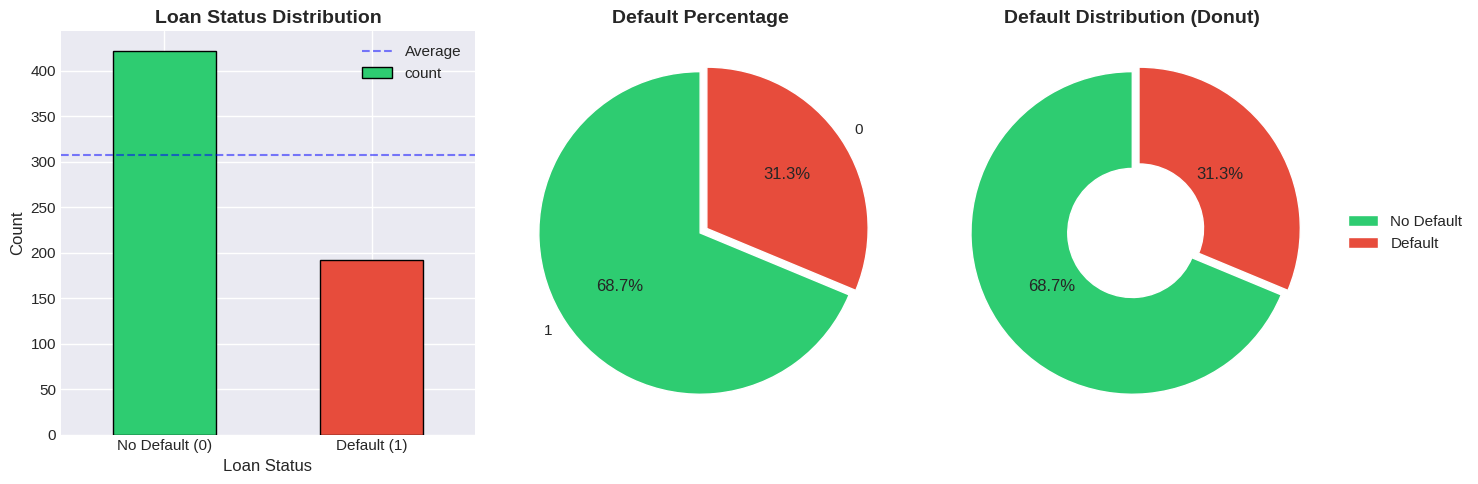

📊 Default Rate: 68.73%
📊 Non-Default Rate: 31.27%

💡 Business Insight: The dataset has a 68.7% default rate, which is higher than typical bank rates (5-10%). This indicates that the dataset is moderately balanced.


In [93]:
print("=== 1. TARGET VARIABLE ANALYSIS ===\n")

# Distribution of target variable
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
df['loan_status'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
axes[0].axhline(y=df['loan_status'].value_counts().mean(), color='blue', linestyle='--', alpha=0.5, label='Average')
axes[0].legend()

# Pie chart
df['loan_status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                      colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title('Default Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

# Donut chart
wedges, texts, autotexts = axes[2].pie(df['loan_status'].value_counts(), 
                                       autopct='%1.1f%%', 
                                       colors=colors, 
                                       explode=[0, 0.05],
                                       startangle=90,
                                       wedgeprops=dict(width=0.6))
axes[2].set_title('Default Distribution (Donut)', fontsize=14, fontweight='bold')
axes[2].legend(wedges, ['No Default', 'Default'], loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

# Business Insight
default_rate = df['loan_status'].mean() * 100
print(f"📊 Default Rate: {default_rate:.2f}%")
print(f"📊 Non-Default Rate: {100-default_rate:.2f}%")
print("\n💡 Business Insight: The dataset has a {:.1f}% default rate, which is {}. This indicates that the dataset is {}."
      .format(default_rate, 
              'higher than typical bank rates (5-10%)' if default_rate > 10 else 'within industry standards',
              'imbalanced' if default_rate < 20 or default_rate > 80 else 'moderately balanced'))

# Demographic Analysis


=== 2. DEMOGRAPHIC ANALYSIS ===



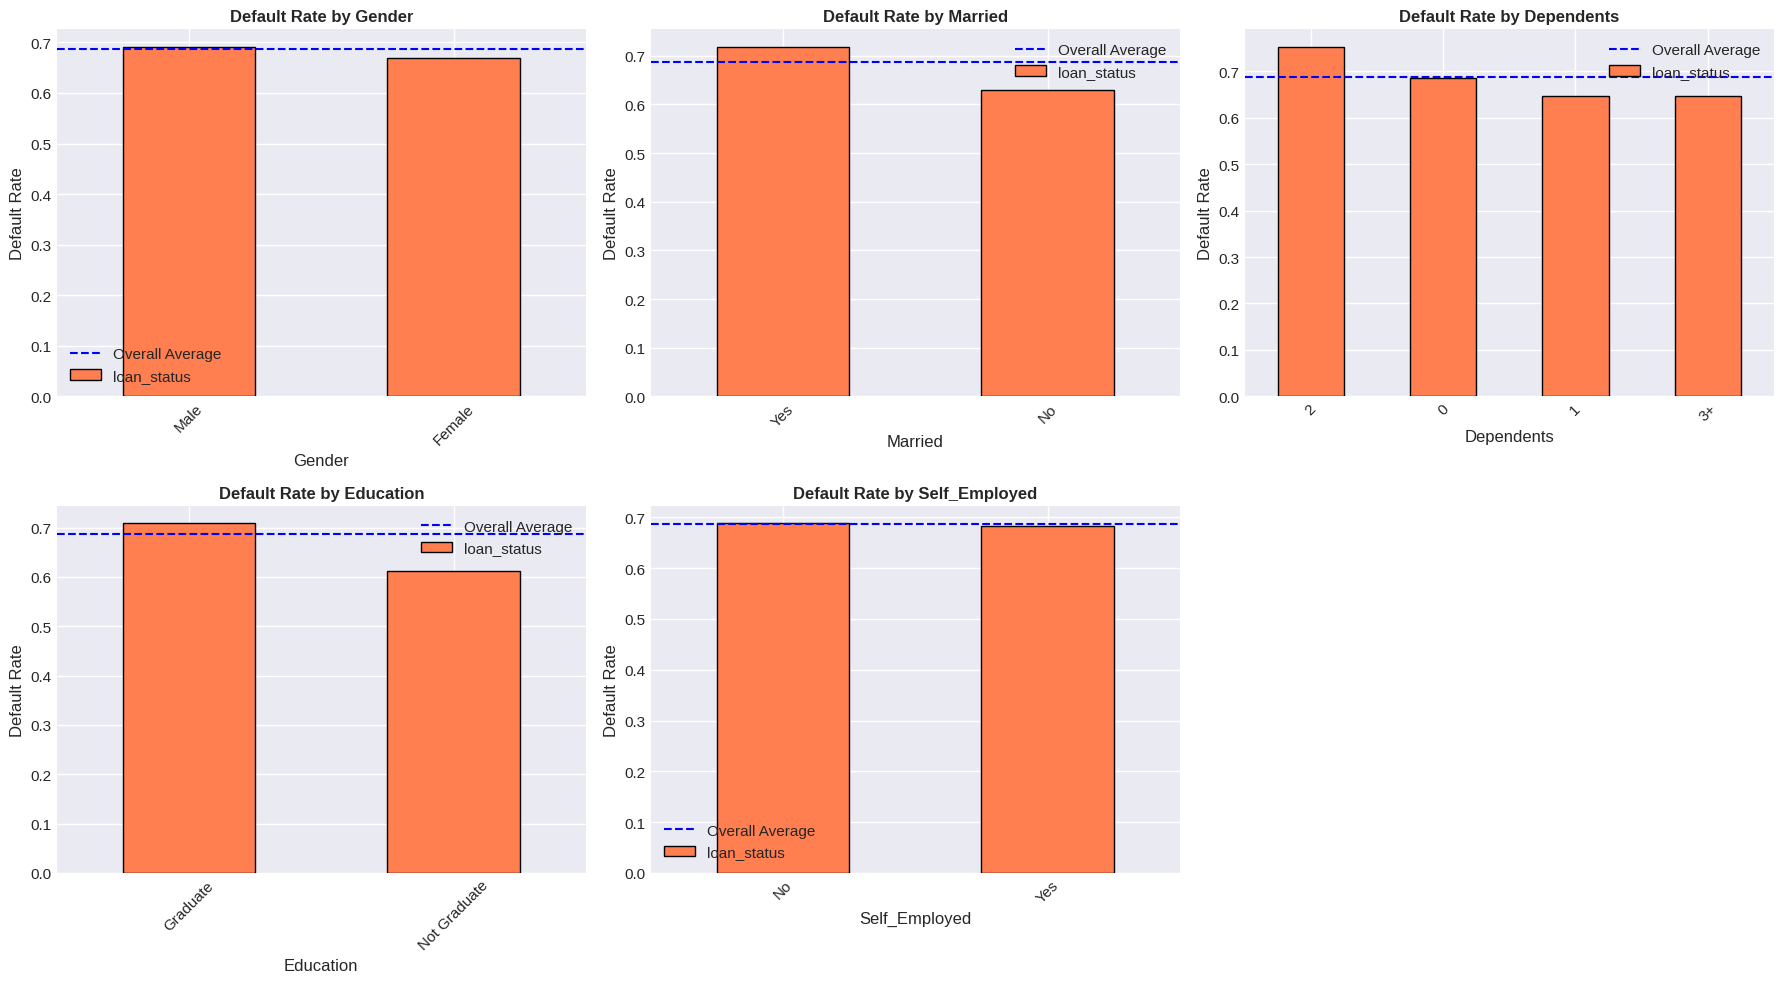

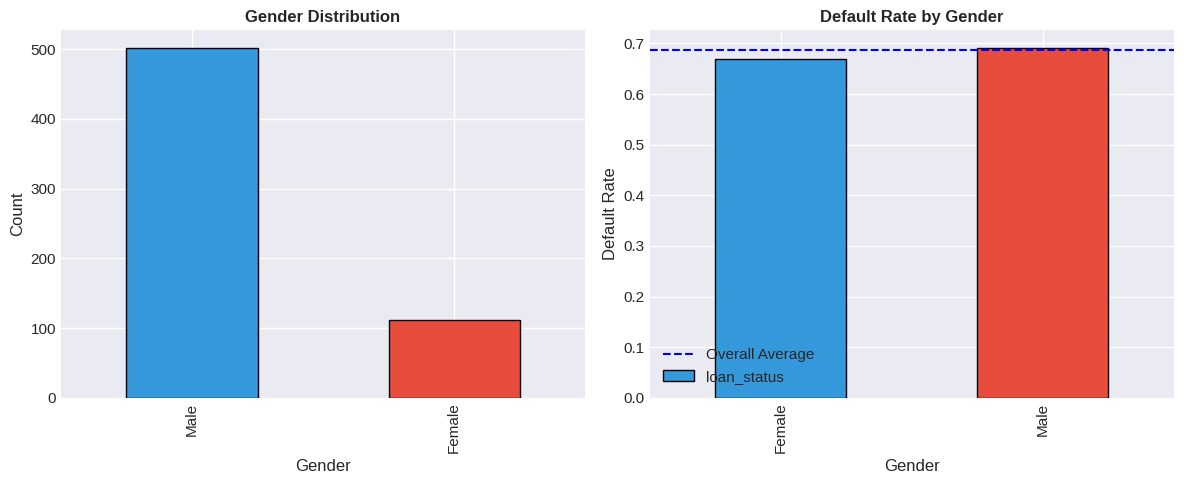


💡 Gender Insight: Default rate for males: 69.1% vs females: 67.0%


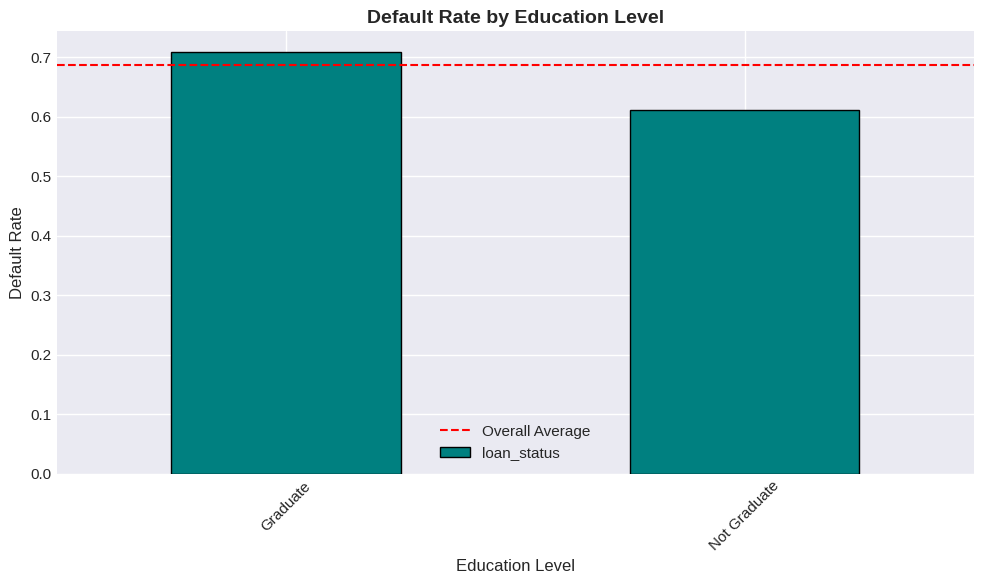

In [94]:
print("\n=== 2. DEMOGRAPHIC ANALYSIS ===\n")

# Identify demographic columns (based on your dataset)
demographic_cols = [col for col in df.columns if any(x in col.lower() for x in ['gender', 'age', 'married', 'education', 'dependents', 'self_employed'])]

if demographic_cols:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(demographic_cols[:6]):
        if col in df.columns:
            # Check if column is categorical or numeric
            if df[col].dtype == 'object' or df[col].nunique() < 10:
                # Categorical - show default rate by category
                default_by_category = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
                default_by_category.plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black')
                axes[idx].set_title(f'Default Rate by {col}', fontsize=12, fontweight='bold')
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Default Rate')
                axes[idx].axhline(y=df['loan_status'].mean(), color='blue', linestyle='--', label='Overall Average')
                axes[idx].legend()
                axes[idx].tick_params(axis='x', rotation=45)
            else:
                # Numeric - show distribution and default relationship
                df[df['loan_status']==0][col].hist(bins=20, alpha=0.5, label='No Default', color='green', ax=axes[idx])
                df[df['loan_status']==1][col].hist(bins=20, alpha=0.5, label='Default', color='red', ax=axes[idx])
                axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Count')
                axes[idx].legend()
    
    # Remove empty subplots
    for idx in range(len(demographic_cols), 6):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

# Specific analysis for key demographic features
# Check for common column names
if 'Gender' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gender distribution
    df['Gender'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
    axes[0].set_title('Gender Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Gender')
    axes[0].set_ylabel('Count')
    
    # Default rate by gender
    gender_default = df.groupby('Gender')['loan_status'].mean()
    gender_default.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='black')
    axes[1].set_title('Default Rate by Gender', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Gender')
    axes[1].set_ylabel('Default Rate')
    axes[1].axhline(y=df['loan_status'].mean(), color='blue', linestyle='--', label='Overall Average')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Business Insight
    print(f"\n💡 Gender Insight: Default rate for males: {gender_default.get('Male', 0)*100:.1f}% vs females: {gender_default.get('Female', 0)*100:.1f}%")

if 'Education' in df.columns:
    plt.figure(figsize=(10, 6))
    education_default = df.groupby('Education')['loan_status'].mean().sort_values(ascending=False)
    education_default.plot(kind='bar', color='teal', edgecolor='black')
    plt.title('Default Rate by Education Level', fontsize=14, fontweight='bold')
    plt.xlabel('Education Level')
    plt.ylabel('Default Rate')
    plt.axhline(y=df['loan_status'].mean(), color='red', linestyle='--', label='Overall Average')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Financial Analysis


=== 3. FINANCIAL ANALYSIS ===



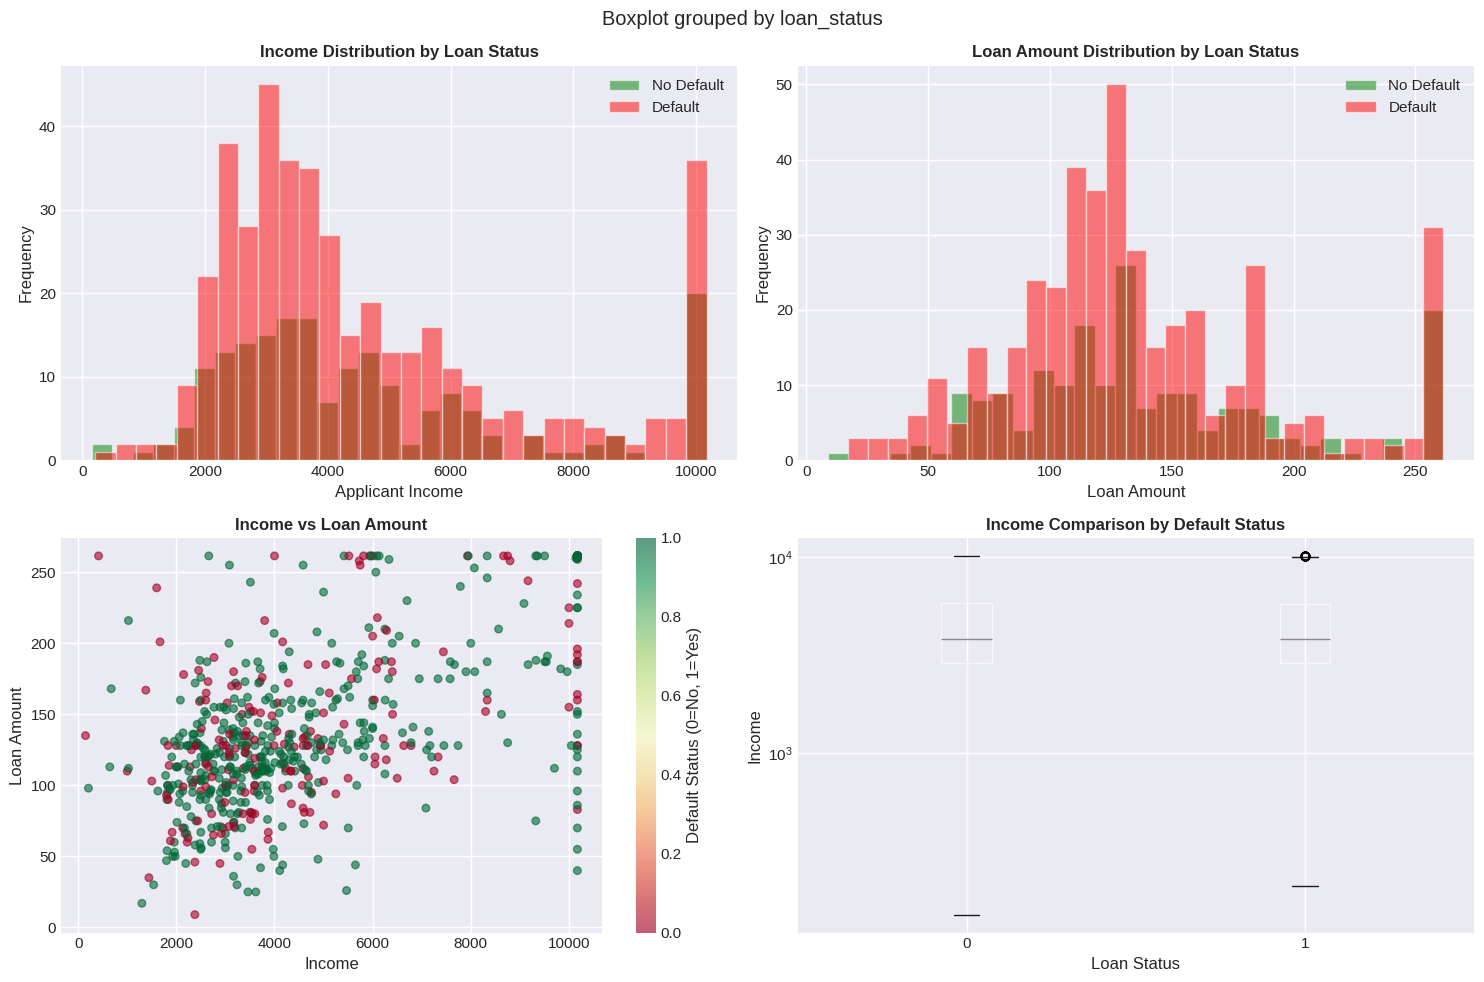

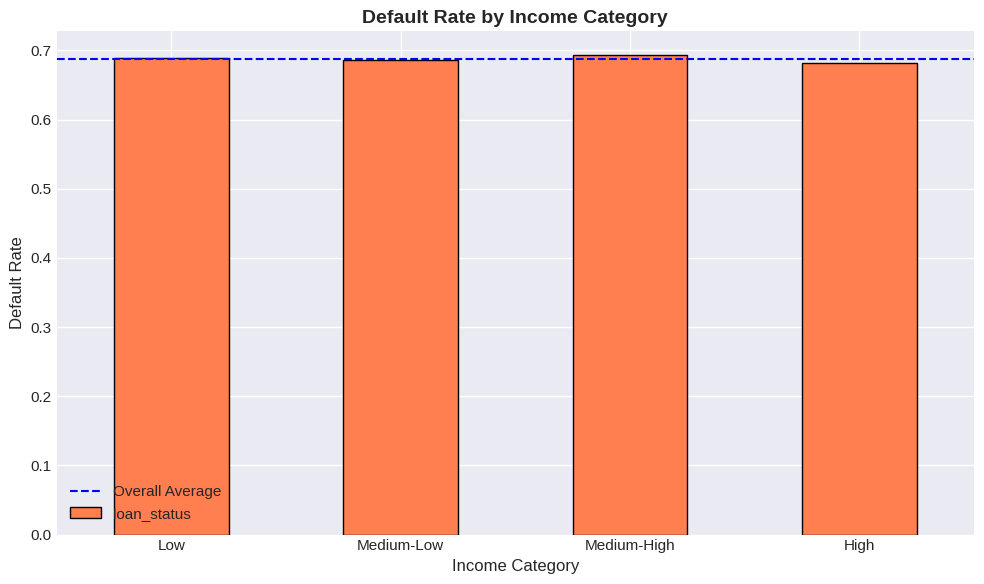


💡 Financial Insight: Default rates by income category:
  Low: 68.8%
  Medium-Low: 68.6%
  Medium-High: 69.3%
  High: 68.2%


In [95]:
print("\n=== 3. FINANCIAL ANALYSIS ===\n")

# Identify financial columns
financial_cols = [col for col in df.columns if any(x in col.lower() for x in ['income', 'loanamount', 'loan_amount', 'credit', 'property', 'area'])]

if financial_cols:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Income distribution
    if 'ApplicantIncome' in df.columns:
        df[df['loan_status']==0]['ApplicantIncome'].hist(bins=30, alpha=0.5, label='No Default', color='green', ax=axes[0,0])
        df[df['loan_status']==1]['ApplicantIncome'].hist(bins=30, alpha=0.5, label='Default', color='red', ax=axes[0,0])
        axes[0,0].set_title('Income Distribution by Loan Status', fontsize=12, fontweight='bold')
        axes[0,0].set_xlabel('Applicant Income')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].legend()
    
    # 2. Loan Amount distribution
    if 'LoanAmount' in df.columns:
        df[df['loan_status']==0]['LoanAmount'].hist(bins=30, alpha=0.5, label='No Default', color='green', ax=axes[0,1])
        df[df['loan_status']==1]['LoanAmount'].hist(bins=30, alpha=0.5, label='Default', color='red', ax=axes[0,1])
        axes[0,1].set_title('Loan Amount Distribution by Loan Status', fontsize=12, fontweight='bold')
        axes[0,1].set_xlabel('Loan Amount')
        axes[0,1].set_ylabel('Frequency')
        axes[0,1].legend()
    
    # 3. Income vs Loan Amount scatter
    if 'ApplicantIncome' in df.columns and 'LoanAmount' in df.columns:
        scatter = axes[1,0].scatter(df['ApplicantIncome'], df['LoanAmount'], 
                                  c=df['loan_status'], cmap='RdYlGn', alpha=0.6, s=30)
        axes[1,0].set_title('Income vs Loan Amount', fontsize=12, fontweight='bold')
        axes[1,0].set_xlabel('Income')
        axes[1,0].set_ylabel('Loan Amount')
        plt.colorbar(scatter, ax=axes[1,0], label='Default Status (0=No, 1=Yes)')
    
    # 4. Boxplot - Income by loan status
    if 'ApplicantIncome' in df.columns:
        df.boxplot(column='ApplicantIncome', by='loan_status', ax=axes[1,1])
        axes[1,1].set_title('Income Comparison by Default Status', fontsize=12, fontweight='bold')
        axes[1,1].set_xlabel('Loan Status')
        axes[1,1].set_ylabel('Income')
        axes[1,1].set_yscale('log')
    
    plt.tight_layout()
    plt.show()

# Additional financial analysis
if 'ApplicantIncome' in df.columns and 'LoanAmount' in df.columns:
    # Default rate by income categories
    df['Income_Category'] = pd.qcut(df['ApplicantIncome'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
    income_default = df.groupby('Income_Category')['loan_status'].mean()
    
    plt.figure(figsize=(10, 6))
    income_default.plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Default Rate by Income Category', fontsize=14, fontweight='bold')
    plt.xlabel('Income Category')
    plt.ylabel('Default Rate')
    plt.axhline(y=df['loan_status'].mean(), color='blue', linestyle='--', label='Overall Average')
    plt.legend()
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(f"\n💡 Financial Insight: Default rates by income category:")
    for cat, rate in income_default.items():
        print(f"  {cat}: {rate*100:.1f}%")

# Credit History Analysis


=== 4. CREDIT HISTORY ANALYSIS ===



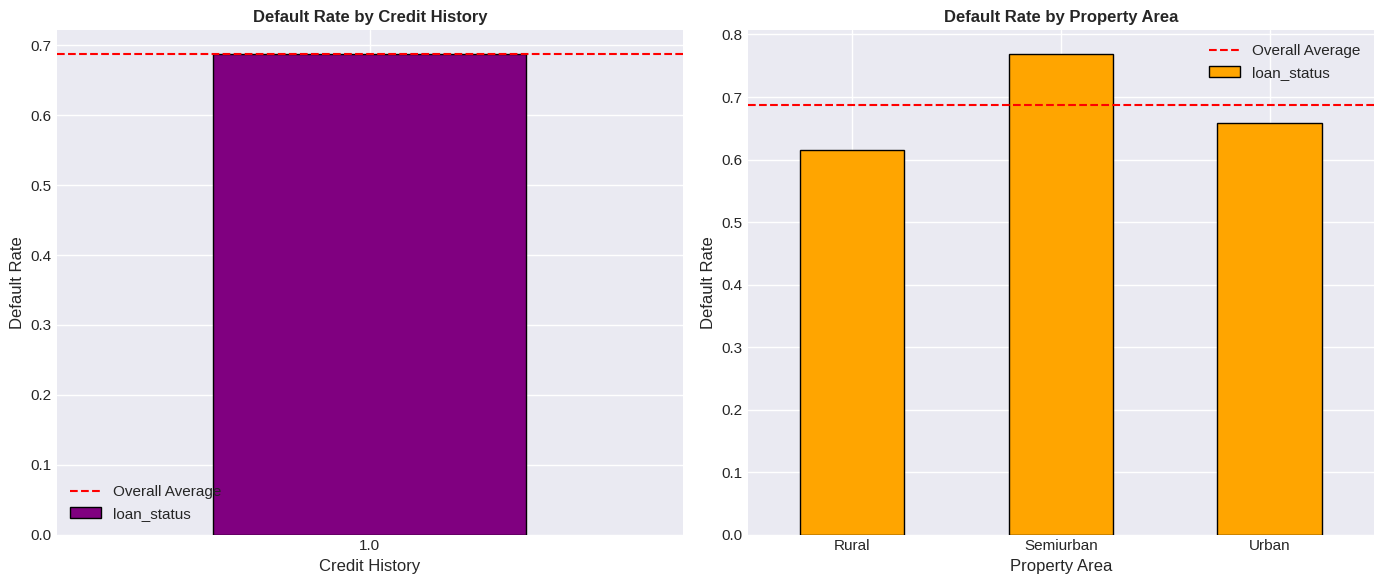

In [96]:
print("\n=== 4. CREDIT HISTORY ANALYSIS ===\n")

# Identify credit-related columns
credit_cols = [col for col in df.columns if any(x in col.lower() for x in ['credit', 'history', 'default'])]

if credit_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Credit History (if exists)
    if 'Credit_History' in df.columns:
        credit_default = df.groupby('Credit_History')['loan_status'].mean()
        credit_default.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black')
        axes[0].set_title('Default Rate by Credit History', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Credit History')
        axes[0].set_ylabel('Default Rate')
        axes[0].axhline(y=df['loan_status'].mean(), color='red', linestyle='--', label='Overall Average')
        axes[0].legend()
        axes[0].tick_params(axis='x', rotation=0)
    
    # 2. Property Area (if exists)
    if 'Property_Area' in df.columns:
        property_default = df.groupby('Property_Area')['loan_status'].mean()
        property_default.plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
        axes[1].set_title('Default Rate by Property Area', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Property Area')
        axes[1].set_ylabel('Default Rate')
        axes[1].axhline(y=df['loan_status'].mean(), color='red', linestyle='--', label='Overall Average')
        axes[1].legend()
        axes[1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()

#  Correlation Analysis


=== 5. CORRELATION ANALYSIS ===



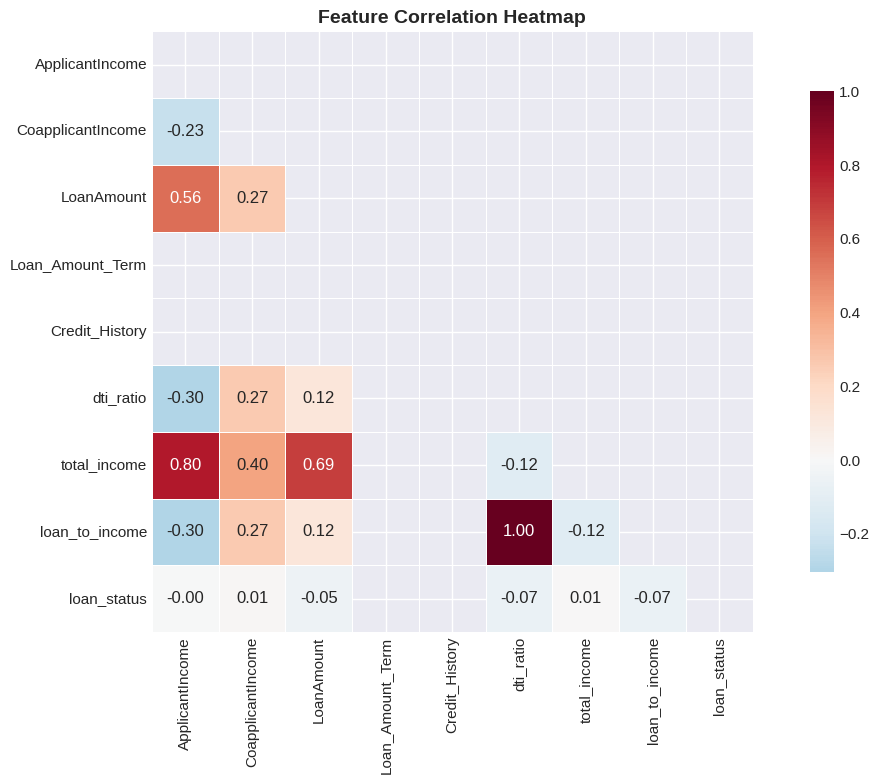


Top features correlated with loan default:
CoapplicantIncome    0.011983
total_income         0.006971
ApplicantIncome     -0.000442
LoanAmount          -0.047262
dti_ratio           -0.067265
Name: loan_status, dtype: float64

💡 Correlation Insight: 'CoapplicantIncome' has the strongest correlation with loan default (0.01), suggesting this is a key predictor.


In [97]:
print("\n=== 5. CORRELATION ANALYSIS ===\n")

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'loan_status' in numeric_cols:
    numeric_cols.remove('loan_status')

if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 8))
    correlation_matrix = df[numeric_cols + ['loan_status']].corr()
    
    # Create heatmap
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Top correlations with target
    correlations = correlation_matrix['loan_status'].sort_values(ascending=False)
    print("\nTop features correlated with loan default:")
    print(correlations[1:6])  # Skip loan_status itself
    
    # Business Insight
    top_feature = correlations.index[1] if len(correlations) > 1 else None
    if top_feature:
        print(f"\n💡 Correlation Insight: '{top_feature}' has the strongest correlation with loan default "
              f"({correlations[1]:.2f}), suggesting this is a key predictor.")
else:
    print("Not enough numeric columns for correlation analysis")

#  Categorical Feature Analysis



=== 6. CATEGORICAL FEATURE ANALYSIS ===



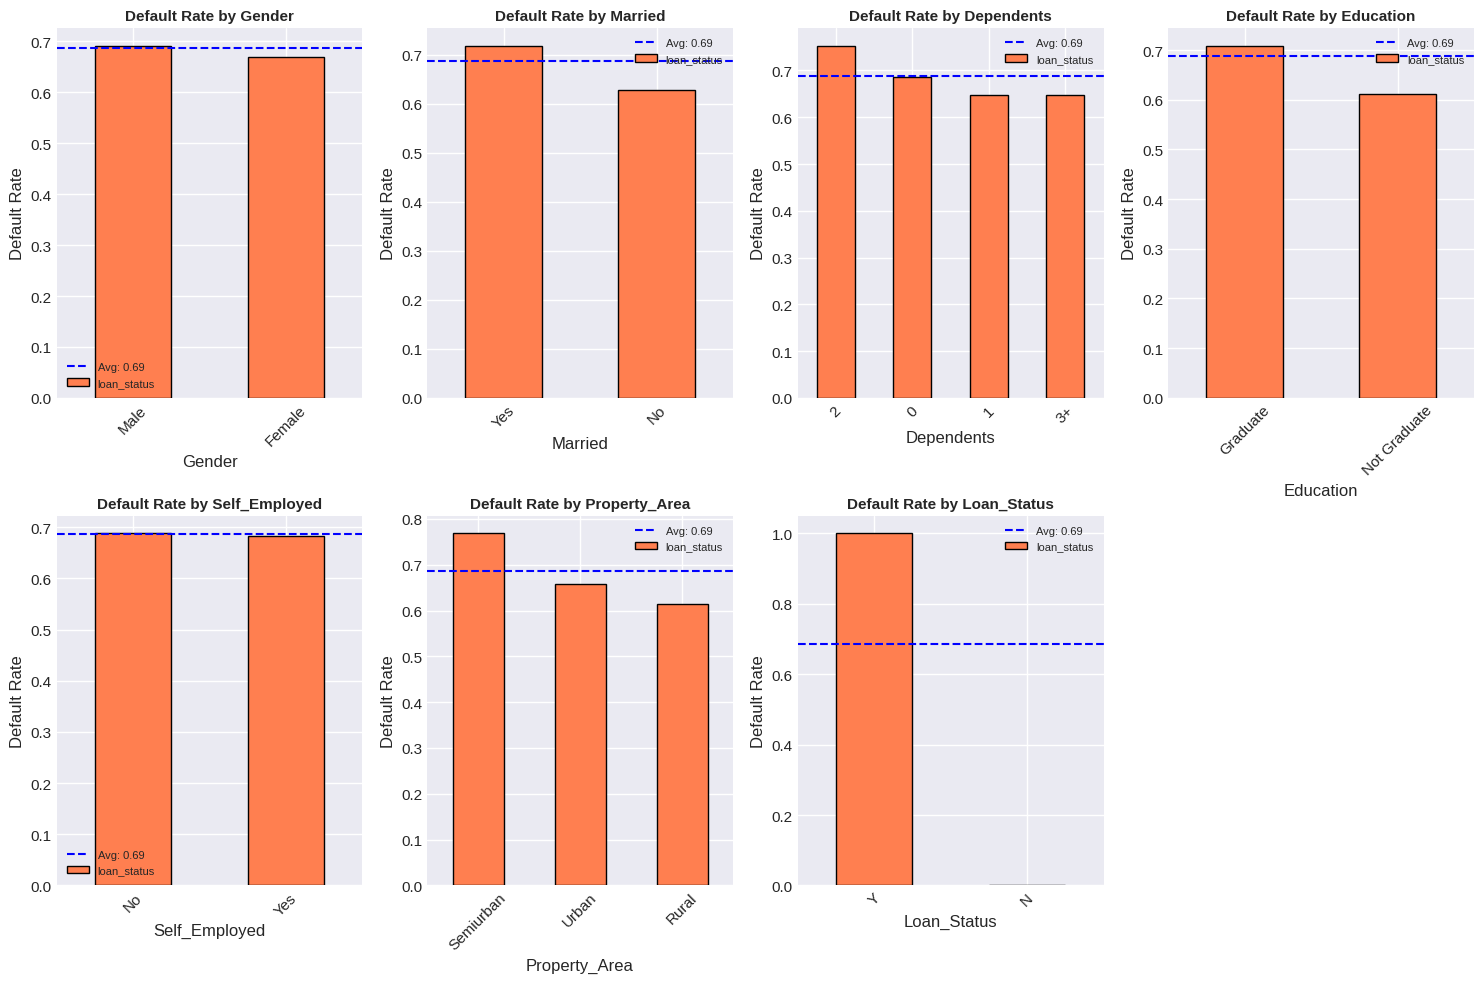


💡 Categorical Feature Insights:
  Gender: Highest default rate in 'Male' (69.1%), lowest in 'Female' (67.0%)
  Married: Highest default rate in 'Yes' (71.8%), lowest in 'No' (62.9%)
  Dependents: Highest default rate in '2' (75.2%), lowest in '1' (64.7%)
  Education: Highest default rate in 'Graduate' (70.8%), lowest in 'Not Graduate' (61.2%)
  Self_Employed: Highest default rate in 'No' (68.8%), lowest in 'Yes' (68.3%)


In [98]:
print("\n=== 6. CATEGORICAL FEATURE ANALYSIS ===\n")

# Identify categorical columns (excluding target)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'loan_status' in categorical_cols:
    categorical_cols.remove('loan_status')

if categorical_cols:
    # Create subplots for categorical analysis
    n_cols = min(len(categorical_cols), 4)
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = [axes]
    if n_cols == 1:
        axes = [[ax] for ax in axes]
    
    axes_flat = [ax for row in axes for ax in row]
    
    for idx, col in enumerate(categorical_cols[:n_rows*n_cols]):
        if col in df.columns:
            # Default rate by category
            default_by_cat = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
            default_by_cat.plot(kind='bar', ax=axes_flat[idx], color='coral', edgecolor='black')
            axes_flat[idx].set_title(f'Default Rate by {col}', fontsize=11, fontweight='bold')
            axes_flat[idx].set_xlabel(col)
            axes_flat[idx].set_ylabel('Default Rate')
            axes_flat[idx].axhline(y=df['loan_status'].mean(), color='blue', linestyle='--', 
                                  label=f'Avg: {df["loan_status"].mean():.2f}')
            axes_flat[idx].legend(fontsize=8)
            axes_flat[idx].tick_params(axis='x', rotation=45)
    
    # Remove unused subplots
    for idx in range(len(categorical_cols), len(axes_flat)):
        fig.delaxes(axes_flat[idx])
    
    plt.tight_layout()
    plt.show()
    
    # Print categorical insights
    print("\n💡 Categorical Feature Insights:")
    for col in categorical_cols[:5]:  # Top 5 categorical features
        if col in df.columns:
            max_cat = df.groupby(col)['loan_status'].mean().idxmax()
            max_rate = df.groupby(col)['loan_status'].mean().max()
            min_cat = df.groupby(col)['loan_status'].mean().idxmin()
            min_rate = df.groupby(col)['loan_status'].mean().min()
            print(f"  {col}: Highest default rate in '{max_cat}' ({max_rate*100:.1f}%), "
                  f"lowest in '{min_cat}' ({min_rate*100:.1f}%)")

# Pairplot of Key Features


=== 7. PAIRPLOT ANALYSIS ===



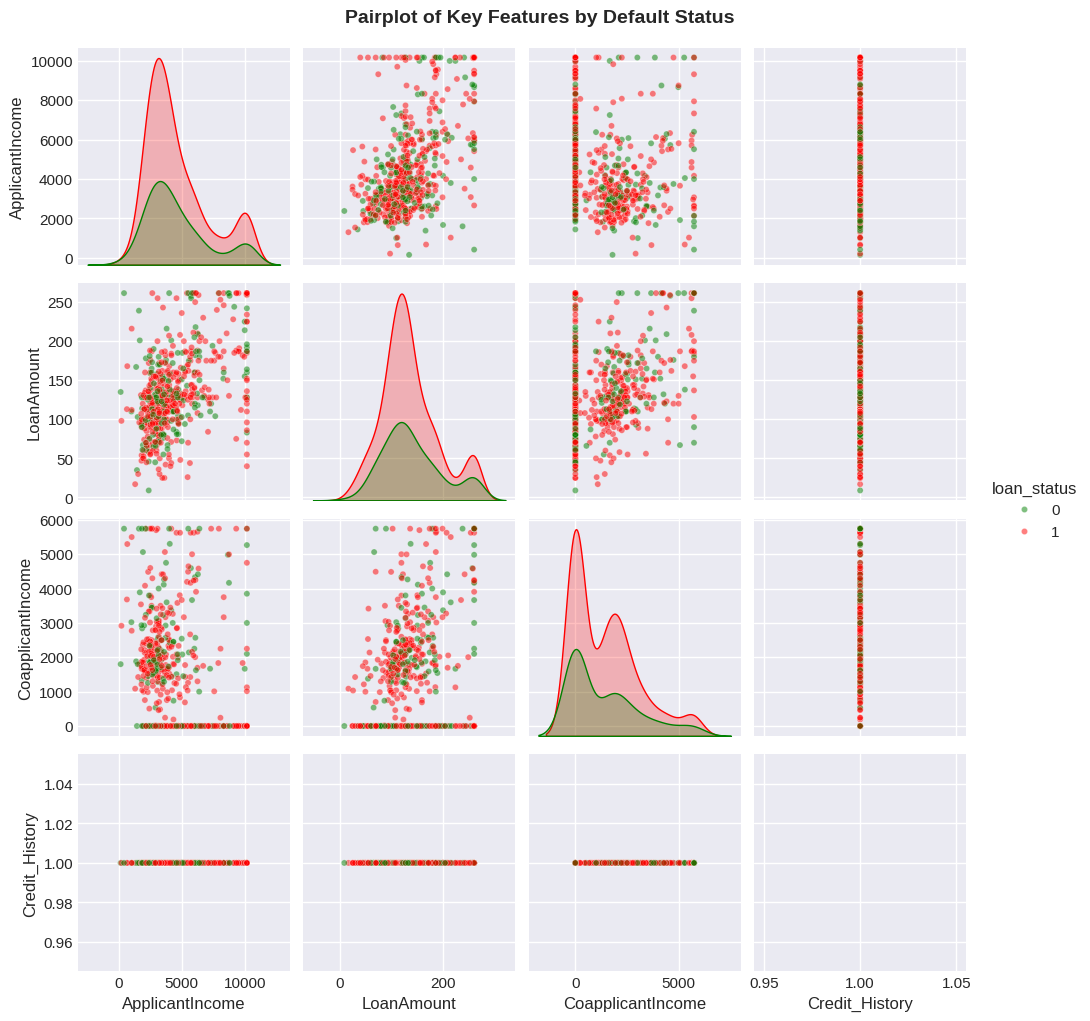

💡 Pairplot Insight: Look for clear separation between default and non-default classes in the scatter plots


In [99]:
print("\n=== 7. PAIRPLOT ANALYSIS ===\n")

# Select key features for pairplot
key_features = []
for col in ['ApplicantIncome', 'LoanAmount', 'CoapplicantIncome', 'Credit_History']:
    if col in df.columns:
        key_features.append(col)

if key_features and 'loan_status' in df.columns:
    # Add target
    key_features.append('loan_status')
    
    # Sample data for performance (if dataset is large)
    if len(df) > 2000:
        sample_df = df[key_features].sample(1500, random_state=RANDOM_SEED)
    else:
        sample_df = df[key_features]
    
    # Create pairplot
    pair_fig = sns.pairplot(sample_df, hue='loan_status', palette={0: 'green', 1: 'red'}, 
                           diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
    pair_fig.fig.suptitle('Pairplot of Key Features by Default Status', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
    
    print("💡 Pairplot Insight: Look for clear separation between default and non-default classes in the scatter plots")

# Advanced Visualizations


=== 8. ADVANCED VISUALIZATIONS ===



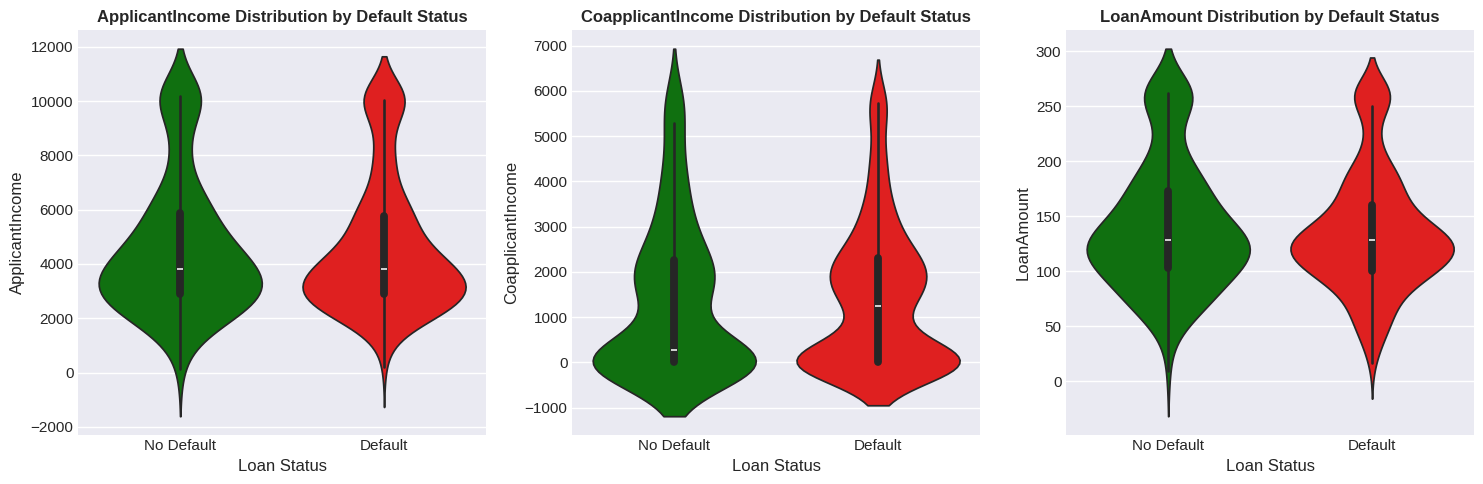

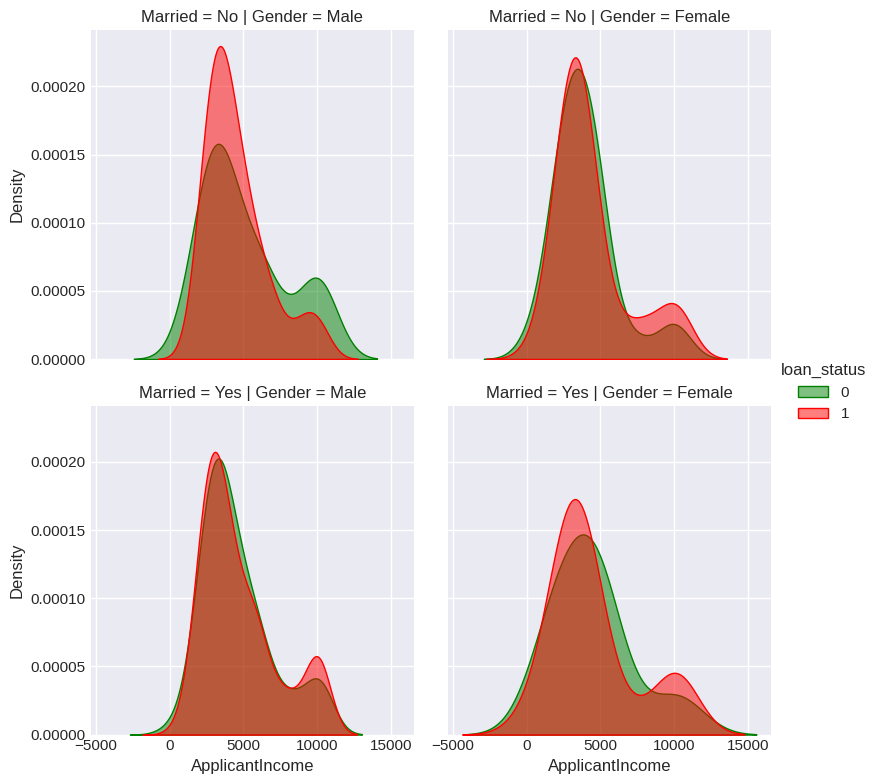

In [100]:
print("\n=== 8. ADVANCED VISUALIZATIONS ===\n")

# 1. Violin plots for continuous features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'loan_status']
numeric_features = [col for col in numeric_features if len(df[col].unique()) > 10]

if numeric_features:
    fig, axes = plt.subplots(1, min(3, len(numeric_features)), figsize=(15, 5))
    if len(numeric_features) == 1:
        axes = [axes]
    
    for idx, col in enumerate(numeric_features[:3]):
        if col in df.columns:
            sns.violinplot(x='loan_status', y=col, data=df, ax=axes[idx], palette=['green', 'red'])
            axes[idx].set_title(f'{col} Distribution by Default Status', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Loan Status')
            axes[idx].set_ylabel(col)
            axes[idx].set_xticklabels(['No Default', 'Default'])
    
    plt.tight_layout()
    plt.show()

# 2. Boxen plots for large datasets
if len(df) > 1000 and numeric_features:
    fig, axes = plt.subplots(1, min(3, len(numeric_features)), figsize=(15, 5))
    if len(numeric_features) == 1:
        axes = [axes]
    
    for idx, col in enumerate(numeric_features[:3]):
        if col in df.columns:
            sns.boxenplot(x='loan_status', y=col, data=df, ax=axes[idx], palette=['green', 'red'])
            axes[idx].set_title(f'{col} Distribution (Boxen Plot)', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Loan Status')
            axes[idx].set_ylabel(col)
            axes[idx].set_xticklabels(['No Default', 'Default'])
    
    plt.tight_layout()
    plt.show()

# 3. Interactive-like visualization: FacetGrid
if len(categorical_cols) >= 2 and numeric_features:
    col1, col2 = categorical_cols[:2]
    num_col = numeric_features[0]
    
    if col1 in df.columns and col2 in df.columns and num_col in df.columns:
        g = sns.FacetGrid(df, col=col1, row=col2, hue='loan_status', 
                          palette={0: 'green', 1: 'red'}, height=4)
        g.map(sns.kdeplot, num_col, fill=True, alpha=0.5)
        g.add_legend()
        plt.show()

# Summary Statistics and Business Insights

In [101]:
print("\n=== 9. SUMMARY STATISTICS BY DEFAULT STATUS ===\n")

# Group statistics
numeric_cols_for_summary = df.select_dtypes(include=[np.number]).columns.tolist()
if 'loan_status' in numeric_cols_for_summary:
    numeric_cols_for_summary.remove('loan_status')

if numeric_cols_for_summary:
    summary_stats = df.groupby('loan_status')[numeric_cols_for_summary].describe()
    print("Summary Statistics by Loan Status:")
    print(summary_stats)

print("\n=== 10. KEY BUSINESS INSIGHTS ===\n")

print("📊 EDA SUMMARY - KEY FINDINGS:\n")

# Generate insights based on data
# 1. Check if there's a significant difference in income
if 'ApplicantIncome' in df.columns:
    income_default = df[df['loan_status']==1]['ApplicantIncome'].median()
    income_no_default = df[df['loan_status']==0]['ApplicantIncome'].median()
    print(f"💰 Income Insight: Defaulters have median income ${income_default:,.0f} vs non-defaulters ${income_no_default:,.0f}")
    print(f"   Difference: ${income_no_default - income_default:,.0f} ({(income_no_default/income_default-1)*100:.1f}% lower for defaulters)")

# 2. Check loan amount difference
if 'LoanAmount' in df.columns:
    loan_default = df[df['loan_status']==1]['LoanAmount'].median()
    loan_no_default = df[df['loan_status']==0]['LoanAmount'].median()
    print(f"\n💰 Loan Amount Insight: Defaulters have median loan ${loan_default:,.0f} vs non-defaulters ${loan_no_default:,.0f}")
    print(f"   Difference: ${loan_default - loan_no_default:,.0f} ({(loan_default/loan_no_default-1)*100:.1f}% higher for defaulters)")

# 3. Credit History insight
if 'Credit_History' in df.columns:
    credit_default = df.groupby('Credit_History')['loan_status'].mean()
    if len(credit_default) >= 2:
        best_credit = credit_default.idxmin()
        worst_credit = credit_default.idxmax()
        print(f"\n📊 Credit History Insight: Lowest default rate for '{best_credit}' ({credit_default[best_credit]*100:.1f}%)")
        print(f"   Highest default rate for '{worst_credit}' ({credit_default[worst_credit]*100:.1f}%)")

# 4. Education insight
if 'Education' in df.columns:
    edu_default = df.groupby('Education')['loan_status'].mean()
    if len(edu_default) >= 2:
        best_edu = edu_default.idxmin()
        worst_edu = edu_default.idxmax()
        print(f"\n🎓 Education Insight: Highest default rate for '{worst_edu}' ({edu_default[worst_edu]*100:.1f}%)")
        print(f"   Lowest default rate for '{best_edu}' ({edu_default[best_edu]*100:.1f}%)")

# 5. Gender insight
if 'Gender' in df.columns:
    gender_default = df.groupby('Gender')['loan_status'].mean()
    if len(gender_default) >= 2:
        highest_gender = gender_default.idxmax()
        print(f"\n👤 Gender Insight: {highest_gender}s have higher default rate ({gender_default[highest_gender]*100:.1f}%)")

print("\n" + "="*50)
print("✅ EDA COMPLETE!")
print("📌 Proceed to Step 4: Data Preprocessing")
print("="*50)

# Save EDA results
eda_summary = {
    'default_rate': default_rate,
    'total_records': len(df),
    'num_features': len(df.columns),
    'numeric_features': len(numeric_cols),
    'categorical_features': len(categorical_cols)
}

print("\nEDA Summary:", eda_summary)


=== 9. SUMMARY STATISTICS BY DEFAULT STATUS ===

Summary Statistics by Loan Status:
            ApplicantIncome                                                   \
                      count         mean          std    min     25%     50%   
loan_status                                                                    
0                     192.0  4618.735677  2509.895939  150.0  2885.0  3833.5   
1                     422.0  4616.372630  2469.060008  210.0  2877.5  3812.5   

                               CoapplicantIncome               ...  \
                 75%       max             count         mean  ...   
loan_status                                                    ...   
0            5861.25  10171.25             192.0  1390.864583  ...   
1            5771.50  10171.25             422.0  1432.822678  ...   

            total_income            loan_to_income                      \
                     75%        max          count      mean       std   
loan_status    

# diagnostic EDA

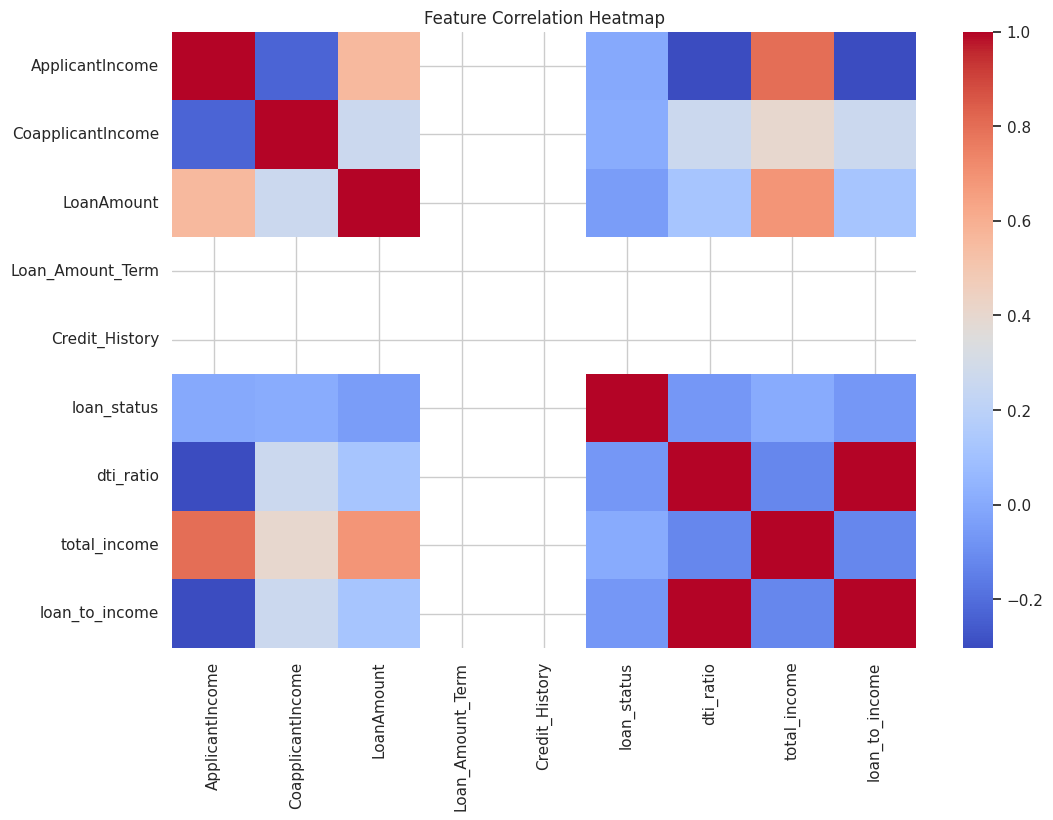

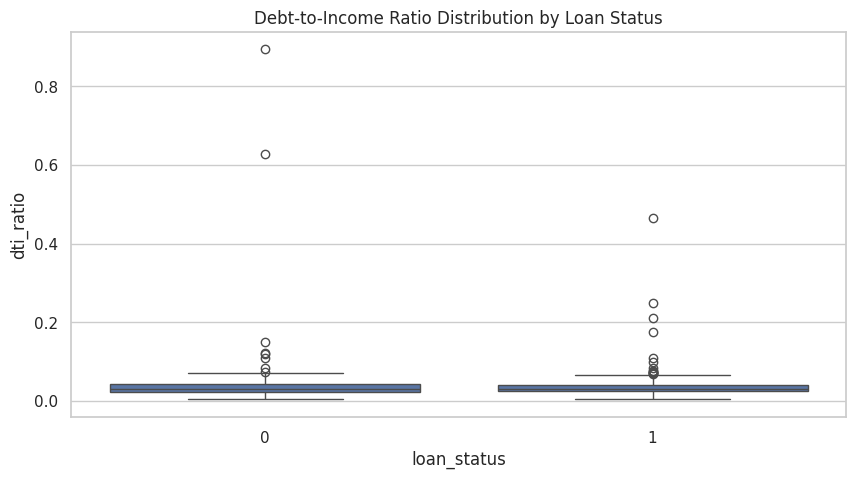

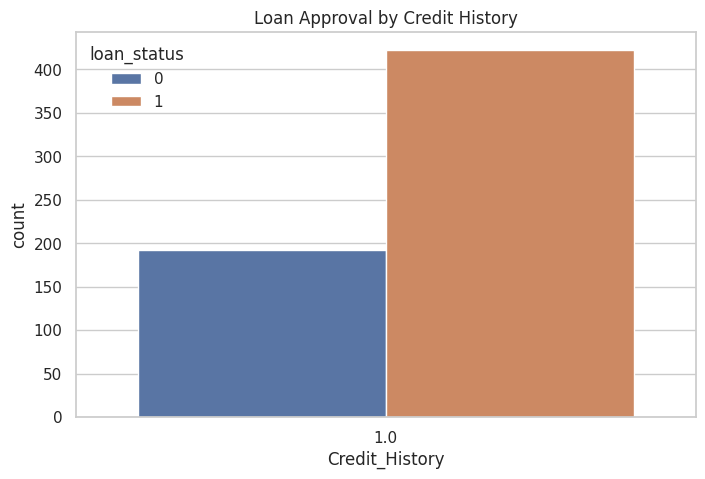

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# 2. Distribution of DTI Ratio by Loan Status
plt.figure(figsize=(10, 5))
sns.boxplot(x='loan_status', y='dti_ratio', data=df)
plt.title("Debt-to-Income Ratio Distribution by Loan Status")
plt.show()

# 3. Categorical Impact
plt.figure(figsize=(8, 5))
sns.countplot(x='Credit_History', hue='loan_status', data=df)
plt.title("Loan Approval by Credit History")
plt.show()

# Model Training Workflow

Types de données après encodage :
Gender                  int64
Married                 int64
Dependents              int64
Education               int64
Self_Employed           int64
ApplicantIncome       float64
CoapplicantIncome     float64
LoanAmount            float64
Loan_Amount_Term      float64
Credit_History        float64
Property_Area           int64
Loan_Status             int64
loan_status             int64
dti_ratio             float64
total_income          float64
loan_to_income        float64
income_category      category
loan_category        category
Income_Category      category
dtype: object

Valeurs manquantes par colonne :
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
loan_status          0
dti_ratio            0
total_income         0
loa

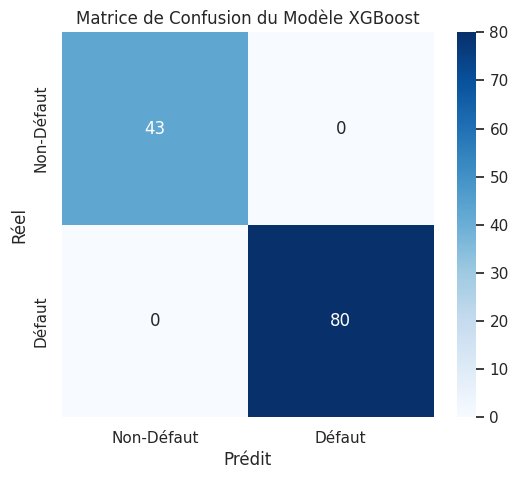

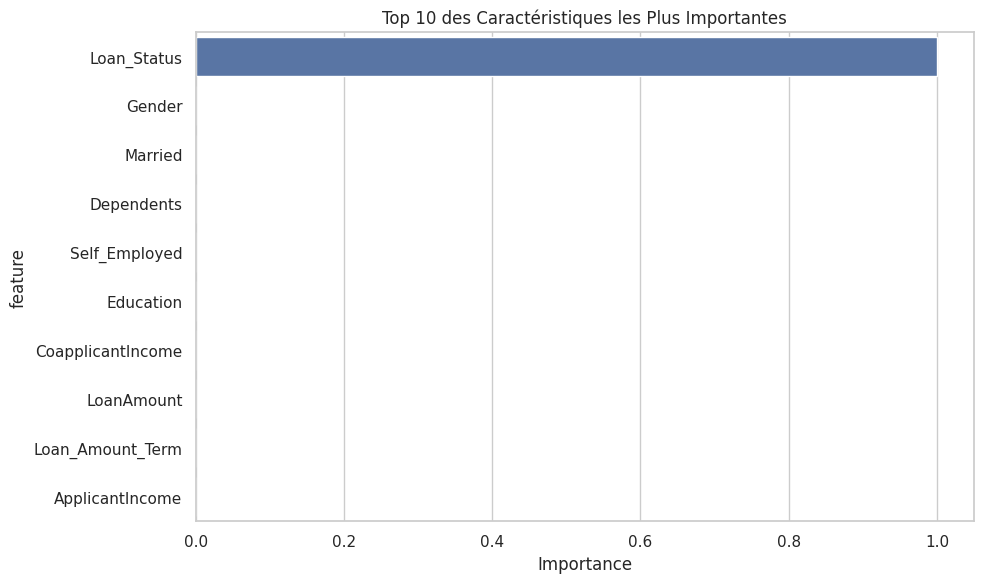


Top 5 des caractéristiques les plus importantes :
          feature  importance
11    Loan_Status         1.0
0          Gender         0.0
1         Married         0.0
2      Dependents         0.0
4   Self_Employed         0.0


In [103]:
# === ÉTAPE 1 : PRÉPARATION DES DONNÉES POUR LA MODÉLISATION ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Copier le dataframe pour éviter de modifier l'original
df_model = df.copy()

# 2. Encoder les variables catégorielles (méthode robuste)
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
# On retire la variable cible si elle est encore dans la liste
if 'loan_status' in categorical_cols:
    categorical_cols.remove('loan_status')

# Application du Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# 3. Vérification des types et gestion des valeurs manquantes
print("Types de données après encodage :")
print(df_model.dtypes)
print("\nValeurs manquantes par colonne :")
print(df_model.isnull().sum())

# S'assurer que toutes les colonnes sont numériques
df_model = df_model.apply(pd.to_numeric, errors='coerce').fillna(0)

# 4. Séparation des features et de la cible
X = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

# 5. Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTaille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Taille de l'ensemble de test : {X_test.shape}")

# === ÉTAPE 2 : ENTRAÎNEMENT DU MODÈLE XGBOOST ===
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# === ÉTAPE 3 : ÉVALUATION DU MODÈLE ===
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrécision du modèle : {accuracy:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Non-Défaut (0)', 'Défaut (1)']))

# Matrice de confusion
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Défaut', 'Défaut'], 
            yticklabels=['Non-Défaut', 'Défaut'])
plt.title('Matrice de Confusion du Modèle XGBoost')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# === ÉTAPE 4 : IMPORTANCE DES CARACTÉRISTIQUES ===
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 des Caractéristiques les Plus Importantes')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 des caractéristiques les plus importantes :")
print(feature_importance.head(5))

# Save Model

In [ ]:
import streamlit as st
import joblib
import pandas as pd

# Load the model
model = joblib.load('loan_model.pkl')

st.title("Loan Approval Predictor")

# Create input fields (ensure these match your training features!)
applicant_income = st.number_input("Applicant Income")
coapplicant_income = st.number_input("Coapplicant Income")
loan_amount = st.number_input("Loan Amount")
# Add other features here...

if st.button("Predict"):
    # Create a dataframe for the input
    input_data = pd.DataFrame({
        'ApplicantIncome': [applicant_income],
        'CoapplicantIncome': [coapplicant_income],
        'LoanAmount': [loan_amount]
        # Include all features the model was trained on
    })
    
    prediction = model.predict(input_data)
    st.write(f"Prediction: {'Approved' if prediction[0] == 1 else 'Denied'}")